## English

This project analyzes real AVIRIS-NG hyperspectral radiance data from the NASA JPL methane benchmark. The objective is to detect CH₄ spectral signatures and quantify methane enhancement in **ppm·m** using spectral processing, machine learning, matched-filter retrieval, and validation.

```math
\boxed{ \text{Spectral Data} \rightarrow \text{Preprocessing} \rightarrow \text{ML Detection} \rightarrow \text{Matched Filter} \rightarrow \text{Quantification} \rightarrow \text{Validation} }
```

JPL CH₄ retrieval products are used for comparison and validation, not as independent ground truth.

---

## 日本語

本プロジェクトでは、NASA JPL のメタン・ベンチマークに含まれる実際の AVIRIS-NG ハイパースペクトル放射輝度データを解析する。目的は、スペクトル処理、機械学習、Matched Filter による Retrieval、および検証を用いて CH₄ のスペクトル特徴を検出し、メタン増強量を **ppm·m** で定量化することである。

```math
\boxed{ \text{スペクトルデータ} \rightarrow \text{前処理} \rightarrow \text{ML検出} \rightarrow \text{Matched Filter} \rightarrow \text{定量化} \rightarrow \text{検証} }
```

JPL の CH₄ retrieval product は、独立した ground truth ではなく、比較・検証用の reference として使用する。


## 01. Project Objective — Data Loading

### English

The objective is to detect methane (CH₄) from AVIRIS-NG hyperspectral radiance data while retaining a clear physical interpretation of the analysis.

For each pixel \((r,c)\), the measured spectrum is:

$$
\mathbf{x}_{r,c} =
[R(\lambda_1), \ldots, R(\lambda_B)]
$$

The project analyzes the CH₄ spectral signature, extracts spectral features, uses machine learning to distinguish **CH₄ from background**, selects CH₄ candidate pixels, applies a matched filter for CH₄ retrieval, and quantifies methane enhancement in **ppm·m**. The results are then compared with the JPL reference product for validation.

---

### 日本語

本プロジェクトの目的は、AVIRIS-NG のハイパースペクトル放射輝度データからメタン（CH₄）を検出し、解析結果を物理的に解釈可能な形で維持することである。

各ピクセル \((r,c)\) における測定スペクトルは次のように表される。

$$
\mathbf{x}_{r,c} =
[R(\lambda_1), \ldots, R(\lambda_B)]
$$

本プロジェクトでは、CH₄ のスペクトル特徴を解析してスペクトル特徴量を抽出し、機械学習を用いて **CH₄ と背景を識別**する。その後、CH₄ 候補ピクセルを選択し、Matched Filter による CH₄ Retrieval を行い、メタン増強量を **ppm·m** で定量化する。最後に、得られた結果を JPL reference product と比較して検証する。


In [1]:
from pathlib import Path
import numpy as np
import spectral
import matplotlib.pyplot as plt
# ============================================================
# 1. PATHS
# ============================================================

# Paths
BASE_DIR = Path(".")

# Data files with radiance
RDN_HDR = BASE_DIR / "ang20160211t075004_rdn_v2m2_clip" / "ang20160211t075004_rdn_v2m2_clip.hdr"

# Data files with CH4 absorption
CH4_HDR = BASE_DIR / "ang20160211t075004_ch4" / "ang20160211t075004_ch4.hdr"

# Data file with CH4 unit absorption reference spectrum
UA_TXT = BASE_DIR / "ang20160211t075004_ch4" / "ang20160211t075004_ch4_ua.txt"


# ============================================================
# 2. LOAD AVIRIS-NG RADIANCE
# ============================================================

rdn_img = spectral.open_image(str(RDN_HDR))
rdn_memmap = rdn_img.open_memmap(interleave="bip")

print("Radiance shape:", rdn_memmap.shape)
print("Radiance dtype:", rdn_memmap.dtype)


# ============================================================
# 3. LOAD WAVELENGTHS
# ============================================================

wavelengths = np.asarray(
    rdn_img.metadata["wavelength"],
    dtype=np.float32
)

print("Number of bands:", len(wavelengths))
print(
    f"Wavelength range: "
    f"{wavelengths.min():.2f}–{wavelengths.max():.2f} nm"
)


# ============================================================
# 4. LOAD JPL CH4 REFERENCE PRODUCT
# ============================================================

ch4_img = spectral.open_image(str(CH4_HDR))
ch4_ref = ch4_img.open_memmap(interleave="bip")

print("CH4 reference shape:", ch4_ref.shape)
print("CH4 reference dtype:", ch4_ref.dtype)


# ============================================================
# 5. LOAD CH4 UNIT ABSORPTION SPECTRUM (UA)
# ============================================================

ua = np.loadtxt(
    UA_TXT,
    comments="#"
)

ua_index = ua[:, 0].astype(np.int32)
ua_wavelength = ua[:, 1].astype(np.float32)
ua_signal = ua[:, 2].astype(np.float32)

print("UA points:", len(ua_wavelength))
print(
    f"UA wavelength range: "
    f"{ua_wavelength.min():.2f}–"
    f"{ua_wavelength.max():.2f} nm"
)
print(
    f"UA signal range: "
    f"{ua_signal.min():.6f}–"
    f"{ua_signal.max():.6f}"
)

Radiance shape: (3987, 598, 425)
Radiance dtype: float32
Number of bands: 425
Wavelength range: 376.44–2500.12 nm
CH4 reference shape: (3987, 598, 5)
CH4 reference dtype: float32
UA points: 212
UA wavelength range: 1443.29–2500.12 nm
UA signal range: -1.248310–0.000000


              425 wavelength bands - 425スペクトルバンド
                  ↑
                  │
          ┌───────────────┐
         /│              /│
        / │             / │
       └───────────────┘  │
       │  │               │ ->column  約598列
       │  └───────────────→ 
       │ /                /
       │/                /
       └────────────────-
              ↓
             row 約3987行 

## 02. Data Quality & EDA

### English

Before spectral processing, the AVIRIS-NG radiance cube, wavelength information, JPL CH₄ reference product, and CH₄ UA signature are checked for consistency and data quality.

This step verifies the dataset dimensions, wavelength coverage, spectral sampling, numerical validity, invalid bands, and the basic statistics of the radiance and reference data.

---

### 日本語

スペクトル処理を行う前に、AVIRIS-NG の放射輝度キューブ、波長情報、JPL の CH₄ reference product、および CH₄ UA シグネチャの整合性とデータ品質を確認する。

このステップでは、データの次元、波長範囲、スペクトル間隔、数値的な有効性、無効なバンド、および放射輝度と reference data の基本統計量を確認する。


Rows:  3,987
Cols:  598
Bands: 425
Pixels: 2,384,226
Wavelengths: 376.44–2500.12 nm
Mean spectral spacing: 5.0087 nm
Shape: (425,) Finite: 425 (100.0%)


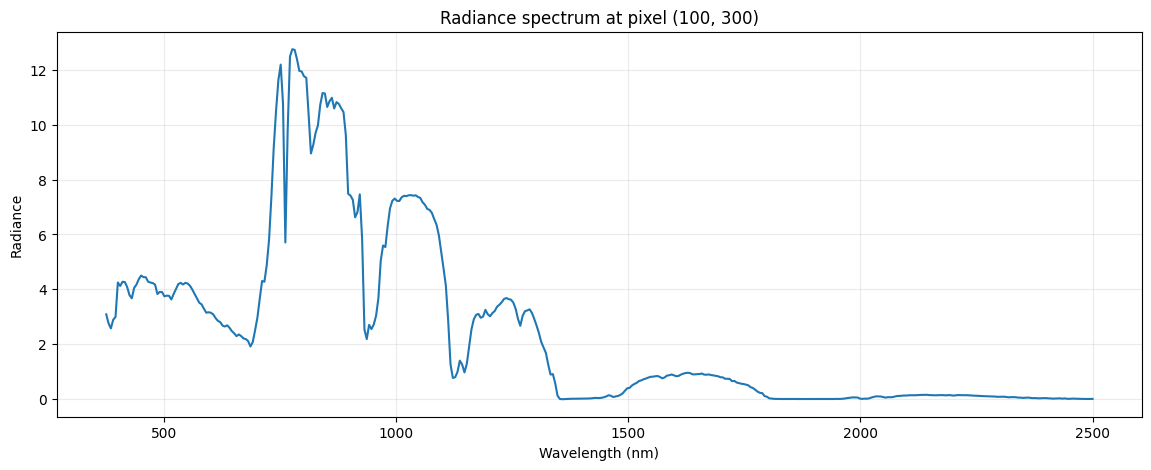

In [2]:
# ============================================================
# 2. DATA QUALITY & EDA
# ============================================================

# ------------------------------------------------------------
# 2.1 Basic dimensions
# ------------------------------------------------------------

n_rows, n_cols, n_bands = rdn_memmap.shape

print(f"Rows:  {n_rows:,}")
print(f"Cols:  {n_cols:,}")
print(f"Bands: {n_bands:,}")
print(f"Pixels: {n_rows * n_cols:,}")


# ------------------------------------------------------------
# 2.2 Wavelength consistency
# ------------------------------------------------------------

assert len(wavelengths) == n_bands

print(
    f"Wavelengths: {wavelengths[0]:.2f}–"
    f"{wavelengths[-1]:.2f} nm"
)

print(
    f"Mean spectral spacing: "
    f"{np.mean(np.diff(wavelengths)):.4f} nm"
)

random_row, random_col = 100, 300

spectrum = np.asarray(
    rdn_memmap[random_row, random_col, :],
    dtype=np.float32
).squeeze()

print(
    "Shape:", spectrum.shape,
    "Finite:", np.isfinite(spectrum).sum(),
    f"({np.isfinite(spectrum).sum() / len(spectrum) * 100:.1f}%)"
)

plt.figure(figsize=(14, 5))
plt.plot(wavelengths, spectrum)
plt.xlabel("Wavelength (nm)")
plt.ylabel("Radiance")
plt.title(f"Radiance spectrum at pixel ({random_row}, {random_col})")
plt.grid(alpha=0.25)
plt.show()


| おおよその波長範囲     | 主な吸収成分           | 主な起源                 |
| ------------- | ---------------- | -------------------- |
| 約400–700 nm   | 色素               | 植生、土壌、鉱物             |
| 約760 nm       | O₂               | 大気中の酸素               |
| 約900–1000 nm  | H₂O              | 水蒸気、大気および地表物質        |
| 約1200 nm      | H₂O              | 大気中の水蒸気、地表物質         |
| 約1400 nm      | **H₂O**          | 水による非常に強い吸収帯         |
| 約1900 nm      | **H₂O**          | 水による非常に強い吸収帯         |
| 約2000–2200 nm | H₂O + 鉱物         | 水、粘土鉱物、炭酸塩鉱物など       |
| 約2120–2485 nm | **CH₄ + その他の寄与** | CH₄検出・解析に利用するスペクトル領域 |



Radiance QC
----------
NaN: 0
Inf: 0
Finite fraction: 1.0
Min: -1.4953908
Max: 19.198013
Mean: 2.424126
Median: 1.2028522
Std: 2.7049682
Negative: 47746
Zero: 0
Negative fraction: 0.4693%
Zero fraction:     0.0000%

Band QC
-------
Total bands: 425
Completely invalid bands: 0

CH4 reference QC
----------------
Shape: (3987, 598, 5)
NaN: 0
Inf: 0
Finite fraction: 1.0
No-data (-9999): 600
No-data fraction: 0.5013%
Valid Min: -0.36951882
Valid Max: 8882.691
Valid Mean: 10.754566
Valid Median: 4.9290733
Valid Std: 82.063995


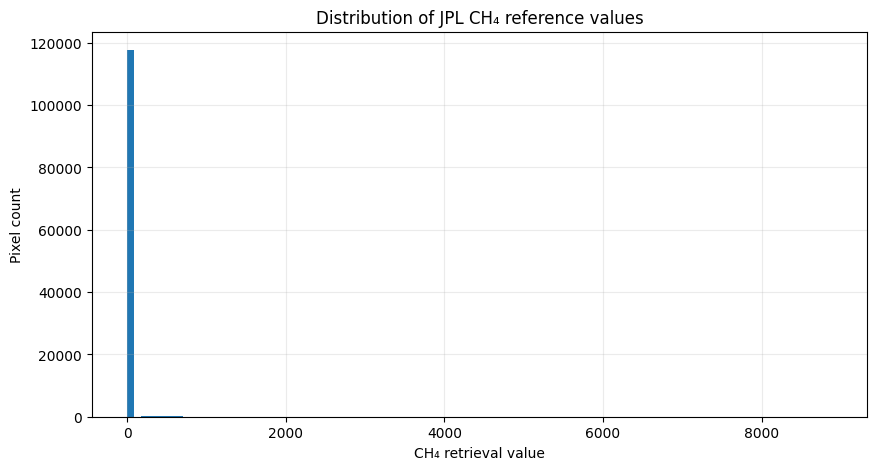

In [3]:

# ------------------------------------------------------------
# 2.3 Sample-based radiance QC
# ------------------------------------------------------------

sample = np.asarray(
    rdn_memmap[::10, ::10, :],
    dtype=np.float32
)

finite_mask = np.isfinite(sample)

print("\nRadiance QC")
print("----------")
print("NaN:", np.isnan(sample).sum())
print("Inf:", np.isinf(sample).sum())
print("Finite fraction:", finite_mask.mean())

finite_values = sample[finite_mask]

print("Min:", finite_values.min())
print("Max:", finite_values.max())
print("Mean:", finite_values.mean())
print("Median:", np.median(finite_values))
print("Std:", finite_values.std())

negative_count = np.sum(sample < 0)
zero_count = np.sum(sample == 0)

print("Negative:", negative_count)
print("Zero:", zero_count)
print(f"Negative fraction: {negative_count / sample.size:.4%}")
print(f"Zero fraction:     {zero_count / sample.size:.4%}")

# ------------------------------------------------------------
# 2.4 Band-level validity
# ------------------------------------------------------------

valid_band_fraction = np.isfinite(sample).mean(axis=(0, 1))

invalid_bands = np.where(valid_band_fraction == 0)[0]

print("\nBand QC")
print("-------")
print("Total bands:", n_bands)
print("Completely invalid bands:", len(invalid_bands))

if len(invalid_bands) > 0:
    print("Invalid band indices:", invalid_bands)
    print(
        "Invalid wavelengths:",
        wavelengths[invalid_bands]
    )


# ------------------------------------------------------------
# 2.5 CH4 reference QC
# ------------------------------------------------------------

ch4_sample = np.asarray(
    ch4_ref[::10, ::10],
    dtype=np.float32
)

ch4_finite = np.isfinite(ch4_sample)
ch4_nodata = ch4_sample == -9999.0

print("\nCH4 reference QC")
print("----------------")
print("Shape:", ch4_ref.shape)
print("NaN:", np.isnan(ch4_sample).sum())
print("Inf:", np.isinf(ch4_sample).sum())
print("Finite fraction:", ch4_finite.mean())
print("No-data (-9999):", ch4_nodata.sum())
print(f"No-data fraction: {ch4_nodata.mean():.4%}")

ch4_valid = ch4_sample[
    ch4_finite & ~ch4_nodata
]

if ch4_valid.size > 0:
    print("Valid Min:", ch4_valid.min())
    print("Valid Max:", ch4_valid.max())
    print("Valid Mean:", ch4_valid.mean())
    print("Valid Median:", np.median(ch4_valid))
    print("Valid Std:", ch4_valid.std())

plt.figure(figsize=(10, 5))
plt.hist(ch4_valid, bins=100)
plt.xlabel("CH₄ retrieval value")
plt.ylabel("Pixel count")
plt.title("Distribution of JPL CH₄ reference values")
plt.grid(alpha=0.25)
plt.show()



UA QC
-----
Points: 212
Wavelength: 1443.29–2500.12 nm
Signal: -1.248310–0.000000


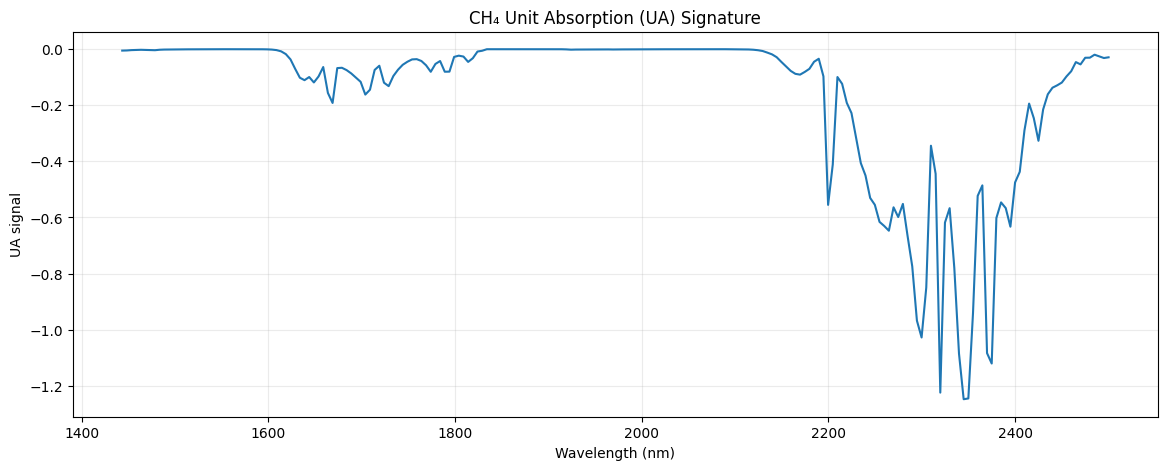

In [4]:

# ------------------------------------------------------------
# 2.6 UA QC
# ------------------------------------------------------------

assert len(ua_wavelength) == len(ua_signal)
assert np.all(np.isfinite(ua_wavelength))
assert np.all(np.isfinite(ua_signal))

print("\nUA QC")
print("-----")
print("Points:", len(ua_wavelength))
print(
    f"Wavelength: {ua_wavelength.min():.2f}–"
    f"{ua_wavelength.max():.2f} nm"
)
print(
    f"Signal: {ua_signal.min():.6f}–"
    f"{ua_signal.max():.6f}"
)

plt.figure(figsize=(14, 5))
plt.plot(ua_wavelength, ua_signal)
plt.xlabel("Wavelength (nm)")
plt.ylabel("UA signal")
plt.title("CH₄ Unit Absorption (UA) Signature")
plt.grid(alpha=0.25)
plt.show()

## 03. CH₄ Spectral Window

### English

This chapter defines the spectral region used for CH₄ analysis in the AVIRIS-NG radiance data.

The CH₄-sensitive spectral window is selected between **2200 and 2400 nm**, where methane absorption features are present in the short-wave infrared region. The corresponding AVIRIS-NG bands are extracted without loading the complete radiance cube into memory.

The same wavelength interval is selected from the CH₄ Unit Absorption (UA) signature. The UA spectrum is then interpolated onto the AVIRIS-NG wavelength grid so that the measured radiance spectra and the CH₄ reference signature have matching spectral coordinates.

The resulting CH₄ radiance window and aligned UA signature are used in the subsequent preprocessing, spectral feature extraction, machine-learning detection, and matched-filter retrieval steps.

---

## 日本語

本章では、AVIRIS-NG の放射輝度データから CH₄ 解析に使用するスペクトル領域を定義する。

CH₄ に感度を持つ **2200–2400 nm** のスペクトル領域を選択する。この領域には短波赤外領域におけるメタンの吸収特徴が含まれている。選択した AVIRIS-NG のバンドのみを抽出し、放射輝度キューブ全体をメモリに読み込むことは避ける。

同じ波長範囲から CH₄ Unit Absorption（UA）シグネチャを抽出する。その後、UA シグネチャを AVIRIS-NG の波長グリッドへ補間し、測定された放射輝度スペクトルと CH₄ の参照シグネチャの波長座標を一致させる。

得られた CH₄ スペクトル領域と波長整合済み UA シグネチャは、後続の前処理、スペクトル特徴量の抽出、機械学習による検出、および Matched Filter による Retrieval に使用する。


In [5]:
# ============================================================
# 3. CH4 SPECTRAL WINDOW
# ============================================================

CH4_MIN_NM = 2200.0
CH4_MAX_NM = 2400.0

# ------------------------------------------------------------
# 3.1 Select AVIRIS-NG bands
# ------------------------------------------------------------

ch4_band_mask = (
    (wavelengths >= CH4_MIN_NM) &
    (wavelengths <= CH4_MAX_NM)
)

ch4_band_idx = np.where(ch4_band_mask)[0]

wl_ch4 = wavelengths[ch4_band_mask]

print("CH4 spectral window")
print("-------------------")
print(f"Range: {CH4_MIN_NM:.1f}–{CH4_MAX_NM:.1f} nm")
print(f"Bands: {len(ch4_band_idx)}")
print(
    f"Actual range: "
    f"{wl_ch4[0]:.2f}-{wl_ch4[-1]:.2f} nm"
)
print(
    f"Mean spacing: "
    f"{np.mean(np.diff(wl_ch4)):.4f} nm"
)


# ------------------------------------------------------------
# 3.2 Extract CH4 radiance bands
# ------------------------------------------------------------

# Do not load the entire cube into RAM.
# Keep the data memory-mapped.

rdn_ch4 = rdn_memmap[:, :, ch4_band_idx]

print("\nCH4 radiance shape:")
print(rdn_ch4.shape)


# ------------------------------------------------------------
# 3.3 Select corresponding UA region
# ------------------------------------------------------------

ua_window_mask = (
    (ua_wavelength >= CH4_MIN_NM) &
    (ua_wavelength <= CH4_MAX_NM)
)

ua_wl_window = ua_wavelength[ua_window_mask]
ua_signal_window = ua_signal[ua_window_mask]

print("\nUA spectral window")
print("------------------")
print(f"Points: {len(ua_wl_window)}")
print(
    f"Range: "
    f"{ua_wl_window[0]:.2f}-{ua_wl_window[-1]:.2f} nm"
)


# ------------------------------------------------------------
# 3.4 Interpolate UA onto AVIRIS-NG wavelength grid
# ------------------------------------------------------------

ua_ch4 = np.interp(
    wl_ch4,
    ua_wl_window,
    ua_signal_window
).astype(np.float32)

print("\nInterpolated UA")
print("----------------")
print(f"Points: {len(ua_ch4)}")
print(
    f"Range: "
    f"{ua_ch4.min():.6f}-{ua_ch4.max():.6f}"
)


# ------------------------------------------------------------
# 3.5 Basic consistency checks for interpolated UA and AVIRIS-NG CH4 bands
# ------------------------------------------------------------

assert len(wl_ch4) == len(ua_ch4)
assert np.all(np.isfinite(wl_ch4))
assert np.all(np.isfinite(ua_ch4))

print("\nConsistency checks: OK")
print("Radiance bands:", rdn_ch4.shape[-1])
print("UA bands:", len(ua_ch4))

CH4 spectral window
-------------------
Range: 2200.0–2400.0 nm
Bands: 40
Actual range: 2204.60-2399.94 nm
Mean spacing: 5.0087 nm

CH4 radiance shape:
(3987, 598, 40)

UA spectral window
------------------
Points: 40
Range: 2204.60-2399.94 nm

Interpolated UA
----------------
Points: 40
Range: -1.248310--0.099212

Consistency checks: OK
Radiance bands: 40
UA bands: 40


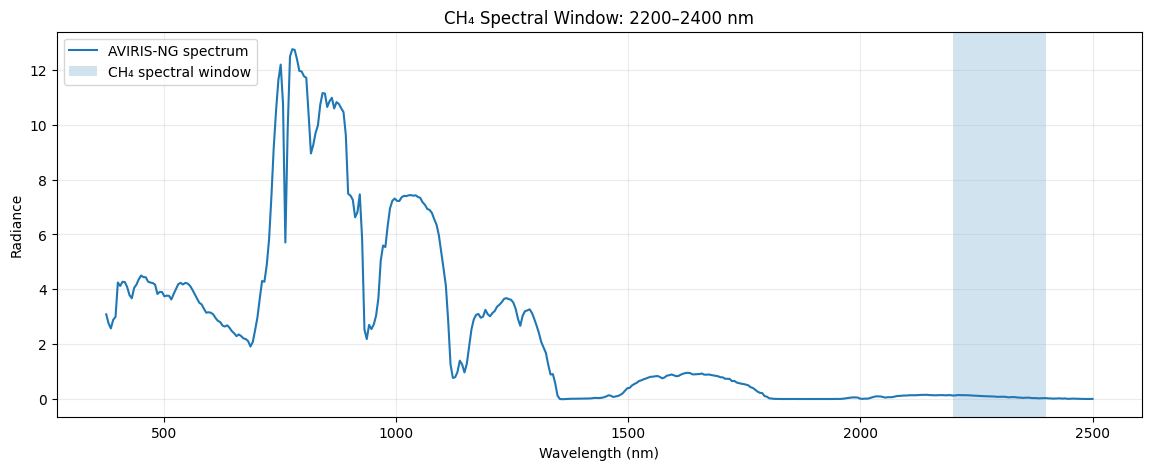

In [6]:
plt.figure(figsize=(14, 5))

plt.plot(
    wavelengths,
    spectrum,
    label="AVIRIS-NG spectrum"
)

plt.axvspan(
    CH4_MIN_NM,
    CH4_MAX_NM,
    alpha=0.2,
    label="CH₄ spectral window"
)

plt.xlabel("Wavelength (nm)")
plt.ylabel("Radiance")
plt.title("CH₄ Spectral Window: 2200–2400 nm")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

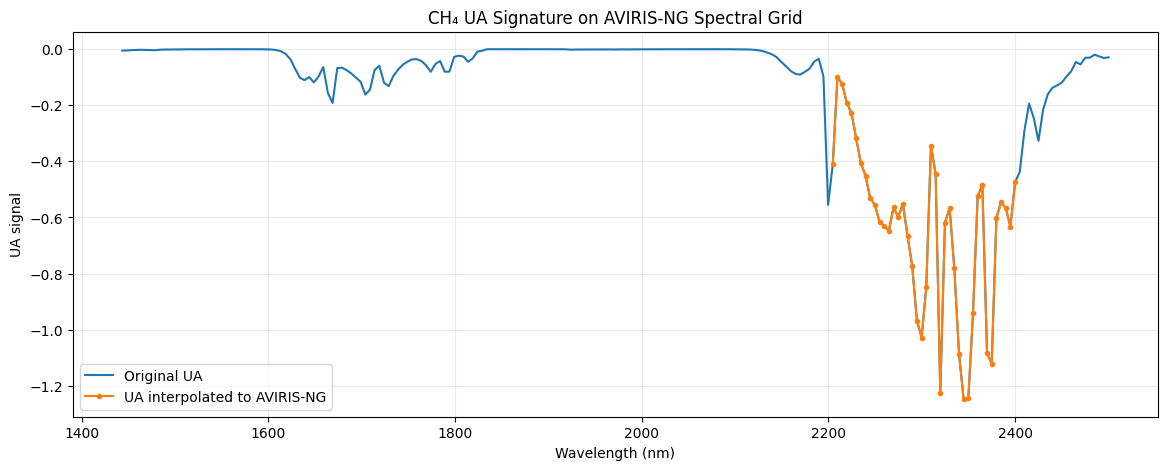

In [7]:
# ------------------------------------------------------------
# 3.7 UA aligned to AVIRIS-NG wavelength grid
# ------------------------------------------------------------

plt.figure(figsize=(14, 5))

plt.plot(
    ua_wavelength,
    ua_signal,
    label="Original UA"
)

plt.plot(
    wl_ch4,
    ua_ch4,
    "o-",
    markersize=3,
    label="UA interpolated to AVIRIS-NG"
)

plt.xlabel("Wavelength (nm)")
plt.ylabel("UA signal")
plt.title("CH₄ UA Signature on AVIRIS-NG Spectral Grid")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

AVIRIS radiance
      ↓
2200–2400 nm
      ↓
valid spectra
      ↓
continuum / albedo normalization
      ↓
Xp_ratio

## 04. Spectral Preprocessing

### English

This chapter preprocesses the CH₄ spectral data selected in the previous chapter before feature extraction and CH₄ detection.

First, pixels containing invalid radiance values within the CH₄ spectral window are removed. The remaining spectra are extracted as valid pixel spectra.

To reduce the influence of the overall spectral shape and background radiance, continuum normalization is then applied. For each spectrum, a linear continuum is estimated between the two endpoints of the CH₄ spectral window, and the measured spectrum is divided by this continuum.

The resulting normalized spectra emphasize relative spectral absorption features rather than absolute radiance levels. These spectra are subsequently used for CH₄ spectral feature extraction, machine-learning detection, and matched-filter retrieval.

---

## 日本語

本章では、前章で選択した CH₄ スペクトル領域のデータに対して、特徴量抽出および CH₄ 検出の前処理を行う。

まず、CH₄ スペクトル領域内に無効な放射輝度値を含むピクセルを除外し、有効なスペクトルのみを抽出する。

次に、スペクトル全体の形状や背景放射輝度の影響を低減するため、Continuum Normalization を行う。各スペクトルについて、CH₄ スペクトル領域の両端を結ぶ線形 Continuum を推定し、測定された放射輝度スペクトルをこの Continuum で除算する。

これにより、絶対的な放射輝度値ではなく、相対的なスペクトル吸収特徴を強調した正規化スペクトルを得る。得られたスペクトルは、後続の CH₄ スペクトル特徴量の抽出、機械学習による検出、および Matched Filter による Retrieval に使用する。


Valid pixels: 2370145
Invalid pixels: 14081
Radiance spectra shape: (2370145, 40)
Valid continuum pixels: 2370145
Rejected pixels: 0


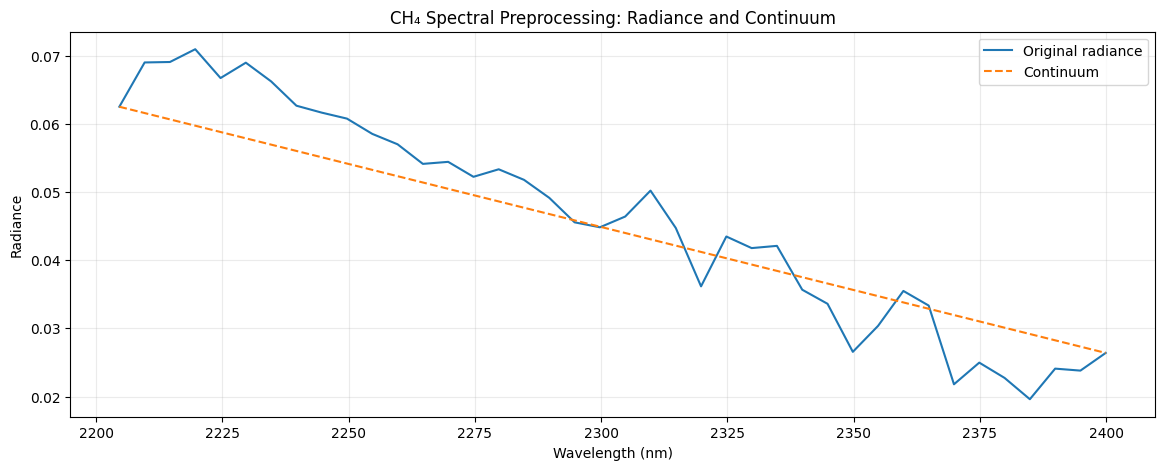

Xp_ratio shape: (2370145, 40)


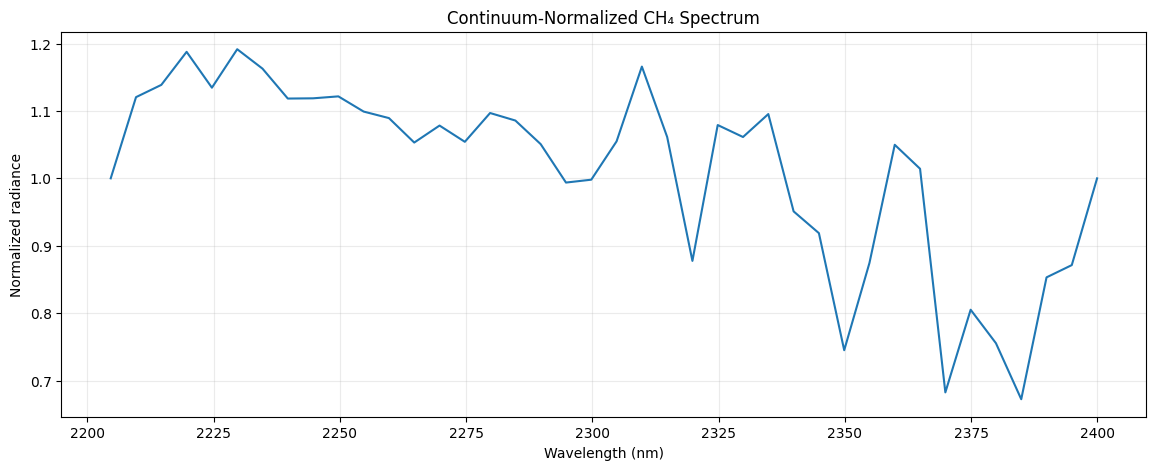


Continuum-normalized spectra
----------------------------
NaN: 0
Inf: 0
Min: 0.0013715754
Max: 37.15812
Mean: 0.9974375
Std: 0.13080025


In [8]:
# ============================================================
# 4. SPECTRAL PREPROCESSING
# ============================================================

# ------------------------------------------------------------
# 4.1 Valid pixels in CH4 spectral window
# ------------------------------------------------------------

rdn_ch4_arr = np.asarray(rdn_ch4, dtype=np.float32)

valid_pixel_mask = np.all(
    np.isfinite(rdn_ch4_arr) & (rdn_ch4_arr > 0),
    axis=2
)

print("Valid pixels:", valid_pixel_mask.sum())
print("Invalid pixels:", (~valid_pixel_mask).sum())

# ------------------------------------------------------------
# 4.2 Extract valid spectra
# ------------------------------------------------------------

X_radiance = rdn_ch4_arr[valid_pixel_mask]

print("Radiance spectra shape:", X_radiance.shape)

# ------------------------------------------------------------
# 4.3 Continuum normalization
# ------------------------------------------------------------

x_left = wl_ch4[0]
x_right = wl_ch4[-1]

left_radiance = X_radiance[:, 0]
right_radiance = X_radiance[:, -1]

continuum = (
    left_radiance[:, None]
    + (
        (right_radiance - left_radiance)[:, None]
        * (wl_ch4[None, :] - x_left)
        / (x_right - x_left)
    )
)

valid_continuum = (
    np.all(np.isfinite(continuum), axis=1)
    & np.all(continuum > 0, axis=1)
)

print("Valid continuum pixels:", valid_continuum.sum())
print("Rejected pixels:", (~valid_continuum).sum())

sample_idx = 0

plt.figure(figsize=(14, 5))

plt.plot(
    wl_ch4,
    X_radiance[valid_continuum][sample_idx],
    label="Original radiance"
)

plt.plot(
    wl_ch4,
    continuum[valid_continuum][sample_idx],
    "--",
    label="Continuum"
)

plt.xlabel("Wavelength (nm)")
plt.ylabel("Radiance")
plt.title("CH₄ Spectral Preprocessing: Radiance and Continuum")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

# ------------------------------------------------------------
# 4.4 Continuum-normalized spectra
# ------------------------------------------------------------

Xp_ratio = (
    X_radiance[valid_continuum]
    / continuum[valid_continuum]
)

print("Xp_ratio shape:", Xp_ratio.shape)

plt.figure(figsize=(14, 5))

plt.plot(
    wl_ch4,
    Xp_ratio[sample_idx]
)

plt.xlabel("Wavelength (nm)")
plt.ylabel("Normalized radiance")
plt.title("Continuum-Normalized CH₄ Spectrum")
plt.grid(alpha=0.25)
plt.show()

# ------------------------------------------------------------
# 4.5 QC of normalized spectra
# ------------------------------------------------------------

print("\nContinuum-normalized spectra")
print("----------------------------")
print("NaN:", np.isnan(Xp_ratio).sum())
print("Inf:", np.isinf(Xp_ratio).sum())
print("Min:", Xp_ratio.min())
print("Max:", Xp_ratio.max())
print("Mean:", Xp_ratio.mean())
print("Std:", Xp_ratio.std())

## 05. CH₄ UA Signature

### English

This chapter prepares the CH₄ Unit Absorption (UA) signature for use as the spectral reference in the following analysis.

The UA signature represents the characteristic spectral response of CH₄ for a unit methane enhancement and is used as the reference spectrum for comparison with the measured AVIRIS-NG spectra.

The UA spectrum selected in the CH₄ spectral window is already aligned with the AVIRIS-NG wavelength grid. Therefore, the UA signature can be directly used in the next chapter to calculate spectral features, including spectral correlation, UA projection, and UA residual.

### 日本語

本章では、後続の解析でスペクトル参照として使用する CH₄ Unit Absorption（UA）シグネチャを準備する。

UA シグネチャは、単位メタン増強量に対する CH₄ の特徴的なスペクトル応答を表し、AVIRIS-NG の測定スペクトルと比較するための参照スペクトルとして使用する。

CH₄ スペクトルウィンドウから抽出した UA シグネチャは、すでに AVIRIS-NG の波長グリッドに補間・整列されている。そのため、次章ではこの UA シグネチャを直接使用して、spectral correlation、UA projection、および UA residual などのスペクトル特徴量を計算する。


CH4 UA Signature
----------------
Points: 40
Wavelength range: 2204.60–2399.94 nm
Signal min: -1.2483096
Signal max: -0.099212125
NaN: 0
Inf: 0


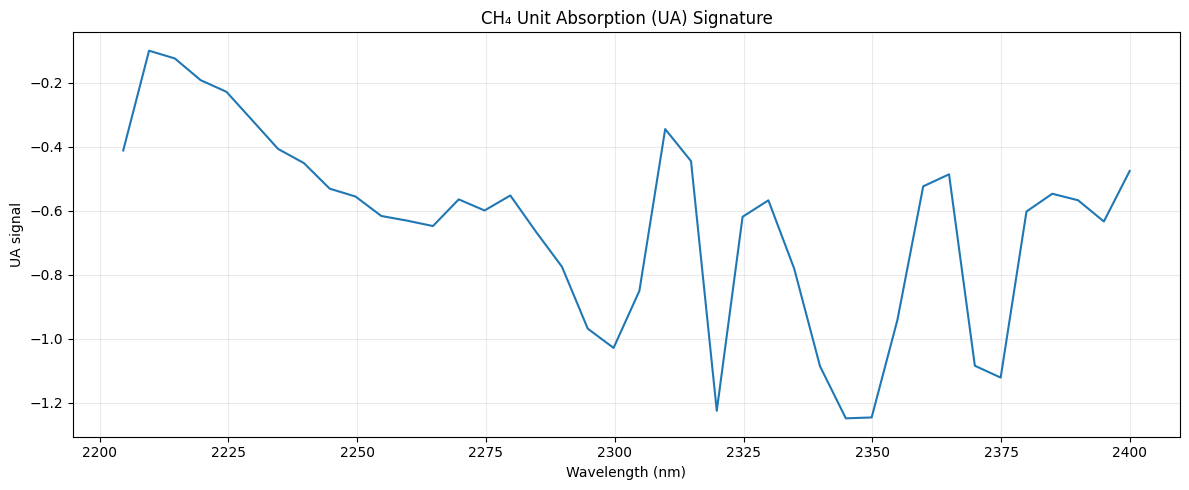

In [28]:
# ============================================================
# 5. CH4 UA SIGNATURE
# ============================================================

ua = ua_ch4.astype(np.float32)

print("CH4 UA Signature")
print("----------------")
print("Points:", len(ua))
print("Wavelength range:",
      f"{wl_ch4[0]:.2f}–{wl_ch4[-1]:.2f} nm")
print("Signal min:", ua.min())
print("Signal max:", ua.max())
print("NaN:", np.isnan(ua).sum())
print("Inf:", np.isinf(ua).sum())

assert len(ua) == len(wl_ch4)
assert np.all(np.isfinite(ua))

plt.figure(figsize=(12, 5))

plt.plot(
    wl_ch4,
    ua
)

plt.xlabel("Wavelength (nm)")
plt.ylabel("UA signal")
plt.title("CH₄ Unit Absorption (UA) Signature")

plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

spectrum
   │
   ├── spectral_corr  → cât de mult seamănă cu CH4
   │
   ├── ua_projection  → cât de puternică este componenta UA
   │
   └── ua_residual    → cât de mult diferă de forma UA

2200–2400 nm spectral bands
        +
CH4 spectral correlation
        +
CH4 UA projection
        +
CH4 residual

## 06. Spectral Features

### English

This chapter converts the preprocessed CH₄ spectra into numerical features that describe their similarity to the CH₄ UA signature.

Three spectral features are calculated for each pixel: **spectral correlation**, **UA projection**, and **UA residual**. Spectral correlation measures the similarity between the spectral shape of a pixel and the CH₄ UA signature. UA projection measures the component of the spectrum aligned with the CH₄ signature, while UA residual measures the spectral component that cannot be represented by the UA projection.

The original 40-band continuum-normalized spectrum is retained together with these three derived features. They are combined into the final **ML feature matrix**, which is used in the next chapter to classify pixels as **CH₄ or background**.

### 日本語

本章では、前章で前処理した CH₄ スペクトルから、CH₄ UA シグネチャとの類似性を表す数値特徴量を抽出する。

各ピクセルについて、**スペクトル相関（spectral correlation）**、**UA projection**、および **UA residual** の3つの特徴量を計算する。スペクトル相関は、ピクセルのスペクトル形状と CH₄ UA シグネチャとの類似度を表す。UA projection は CH₄ シグネチャと一致するスペクトル成分の大きさを表し、UA residual は UA projection では表現できないスペクトル成分の大きさを表す。

元の40バンドの Continuum-normalized spectrum にこれら3つの特徴量を追加し、最終的な **ML feature matrix** を構成する。この特徴量行列は、次章で **CH₄ と背景を分類する機械学習モデル**への入力として使用する。


In [11]:
# ============================================================
# 6. SPECTRAL FEATURES
# ============================================================

ua = ua_ch4.astype(np.float32)

# ------------------------------------------------------------
# 6.1 Spectral correlation with CH4 UA
# ------------------------------------------------------------

ua_centered = ua - ua.mean()

X_centered = (
    Xp_ratio -
    Xp_ratio.mean(axis=1, keepdims=True)
)

ua_norm = np.linalg.norm(ua_centered)

X_norm = np.linalg.norm(
    X_centered,
    axis=1
)

spectral_corr = (
    X_centered @ ua_centered
    / (X_norm * ua_norm + 1e-12)
)

print("Spectral correlation")
print("--------------------")
print("Min :", spectral_corr.min())
print("Max :", spectral_corr.max())
print("Mean:", spectral_corr.mean())
print("Std :", spectral_corr.std())


# ------------------------------------------------------------
# 6.2 Projection onto CH4 UA
# ------------------------------------------------------------

ua_energy = np.dot(
    ua,
    ua
)

ua_projection = (
    Xp_ratio @ ua
    / (ua_energy + 1e-12)
)

print("\nUA projection")
print("-------------")
print("Min :", ua_projection.min())
print("Max :", ua_projection.max())
print("Mean:", ua_projection.mean())
print("Std :", ua_projection.std())


# ------------------------------------------------------------
# 6.3 Residual after UA projection
# ------------------------------------------------------------

X_reconstructed = (
    ua_projection[:, None]
    * ua[None, :]
)

ua_residual = np.linalg.norm(
    Xp_ratio - X_reconstructed,
    axis=1
)

print("\nUA residual")
print("-----------")
print("Min :", ua_residual.min())
print("Max :", ua_residual.max())
print("Mean:", ua_residual.mean())
print("Std :", ua_residual.std())


# ------------------------------------------------------------
# 6.4 ML feature matrix
# ------------------------------------------------------------

X_ml = np.column_stack([
    Xp_ratio,
    spectral_corr,
    ua_projection,
    ua_residual
]).astype(np.float32)

print("\nX_ml")
print("----")
print("Shape:", X_ml.shape)
print("NaN:", np.isnan(X_ml).sum())
print("Inf:", np.isinf(X_ml).sum())

assert np.all(np.isfinite(X_ml))

Spectral correlation
--------------------
Min : -0.56668705
Max : 0.8593748
Mean: 0.63383436
Std : 0.069078885

UA projection
-------------
Min : -8.406009
Max : -0.68206984
Mean: -1.2313095
Std : 0.049477607

UA residual
-----------
Min : 2.1051624
Max : 51.283627
Mean: 3.140782
Std : 0.22778253

X_ml
----
Shape: (2370145, 43)
NaN: 0
Inf: 0


## 07. ML: CH₄ vs Background

### English

This chapter uses the extracted spectral features to train a machine-learning classifier that distinguishes **CH₄ pixels from background pixels**.

The JPL CH₄ matched-filter product is used to define the binary training labels. Pixels above the **98th percentile** of the JPL reference values are classified as CH₄ candidates, while the remaining pixels are treated as background. This percentile is a statistical threshold used to construct the classification dataset; it is not a physical CH₄ concentration threshold.

The feature matrix is divided into training and test sets using a stratified split to preserve the CH₄/background ratio. A **LightGBM binary classifier** is then trained with class weighting to account for the strong imbalance between background and CH₄ pixels.

The trained model provides the CH₄ probability for each pixel and is used in the next chapter to select **CH₄ candidate pixels** for subsequent matched-filter retrieval.

### 日本語

本章では、前章で抽出したスペクトル特徴量を用いて、**CH₄ ピクセルと背景ピクセルを識別する機械学習モデル**を構築する。

JPL の CH₄ matched-filter product を利用して、二値分類用のラベルを作成する。JPL reference の **98パーセンタイル**以上のピクセルを CH₄ candidate とし、それ以外を background とする。このパーセンタイルは分類データを作成するための統計的なしきい値であり、物理的な CH₄ 濃度のしきい値ではない。

作成した特徴量行列を、CH₄ と background の比率を維持する stratified split により学習データとテストデータに分割する。その後、クラス間の大きな不均衡を考慮するため class weight を使用し、**LightGBM binary classifier** を学習する。

学習したモデルから各ピクセルの CH₄ probability を取得し、次章で **CH₄ candidate pixels** を選択する。その後、選択された候補に対して Matched Filter による Retrieval を行う。


In [12]:
# ============================================================
# 7. ML: CH4 vs BACKGROUND
# ============================================================

# ------------------------------------------------------------
# 7.1 Extract JPL CH4 matched-filter product
# ------------------------------------------------------------

ch4_ref_2d = np.asarray(
    ch4_ref[:, :, 2],
    dtype=np.float32
)

print("JPL CH4 band:", ch4_ref_2d.shape)

assert ch4_ref_2d.shape == valid_pixel_mask.shape


# ------------------------------------------------------------
# 7.2 Apply exactly the same masks as X_ml
# ------------------------------------------------------------

ch4_ref_valid = ch4_ref_2d[
    valid_pixel_mask
]

ch4_ref_ml = ch4_ref_valid[
    valid_continuum
]

ch4_ref_ml = np.asarray(
    ch4_ref_ml,
    dtype=np.float32
)

print("JPL reference:", ch4_ref_ml.shape)
print("X_ml:", X_ml.shape)

assert ch4_ref_ml.shape[0] == X_ml.shape[0]
assert np.all(np.isfinite(ch4_ref_ml))


# ------------------------------------------------------------
# 7.3 Define CH4 detection threshold
# ------------------------------------------------------------

CH4_THRESHOLD = np.percentile(
    ch4_ref_ml,
    98
)

print("\nCH4 threshold")
print("-------------")
print(f"{CH4_THRESHOLD:.6f} ppm·m")


# ------------------------------------------------------------
# 7.4 Create binary labels
# ------------------------------------------------------------

y = (
    ch4_ref_ml >= CH4_THRESHOLD
).astype(np.int8)

print("\nLabels")
print("------")
print("Background:", (y == 0).sum())
print("CH4       :", (y == 1).sum())
print("CH4 fraction:", y.mean())

assert X_ml.shape[0] == y.shape[0]


# ------------------------------------------------------------
# 7.5 Train / test split
# ------------------------------------------------------------

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_ml,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print("\nTrain:", X_train.shape)
print("Test :", X_test.shape)

print("\nTrain")
print("-----")
print("Background:", (y_train == 0).sum())
print("CH4       :", (y_train == 1).sum())

print("\nTest")
print("----")
print("Background:", (y_test == 0).sum())
print("CH4       :", (y_test == 1).sum())


# ------------------------------------------------------------
# 7.6 LightGBM
# ------------------------------------------------------------

from lightgbm import LGBMClassifier

n_background = (y_train == 0).sum()
n_ch4 = (y_train == 1).sum()

scale_pos_weight = (
    n_background / n_ch4
)

print("\nClass weight:")
print(scale_pos_weight)

clf = LGBMClassifier(
    objective="binary",
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31,
    max_depth=-1,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1
)

clf.fit(
    X_train,
    y_train
)

JPL CH4 band: (3987, 598)
JPL reference: (2370145,)
X_ml: (2370145, 43)

CH4 threshold
-------------
10.695106 ppm·m

Labels
------
Background: 2322742
CH4       : 47403
CH4 fraction: 0.02000004219151149

Train: (1896116, 43)
Test : (474029, 43)

Train
-----
Background: 1858194
CH4       : 37922

Test
----
Background: 464548
CH4       : 9481

Class weight:
49.00042191867517
[LightGBM] [Info] Number of positive: 37922, number of negative: 1858194
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.128831 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 10466
[LightGBM] [Info] Number of data points in the train set: 1896116, number of used features: 42
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.020000 -> initscore=-3.891829
[LightGBM] [Info] Start training from score -3.891829


,learning_rate,0.05
,n_estimators,300
,objective,'binary'
,subsample,0.8
,colsample_bytree,0.8
,random_state,42
,n_jobs,-1
,scale_pos_weight,np.float64(49.00042191867517)
,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1


In [13]:
# ============================================================
# 7.7 ML EVALUATION
# ============================================================

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score
)

y_pred = clf.predict(X_test)

y_prob = clf.predict_proba(
    X_test
)[:, 1]

print("\nClassification report")
print("---------------------")

print(
    classification_report(
        y_test,
        y_pred,
        digits=4
    )
)

print("\nConfusion matrix")
print("----------------")

print(
    confusion_matrix(
        y_test,
        y_pred
    )
)

print("\nROC-AUC")
print("-------")

print(
    roc_auc_score(
        y_test,
        y_prob
    )
)


Classification report
---------------------
              precision    recall  f1-score   support

           0     0.9982    0.9047    0.9492    464548
           1     0.1649    0.9222    0.2797      9481

    accuracy                         0.9050    474029
   macro avg     0.5816    0.9134    0.6144    474029
weighted avg     0.9816    0.9050    0.9358    474029


Confusion matrix
----------------
[[420259  44289]
 [   738   8743]]

ROC-AUC
-------
0.9701933725563348


## 08. CH₄ Candidate Pixels

### English

This chapter applies the trained machine-learning classifier to all valid pixels to identify potential CH₄ locations.

The model produces a **CH₄ probability** for each valid pixel. Pixels with a predicted probability of at least **0.50** are selected as CH₄ candidates. This threshold is used to separate pixels classified by the model as CH₄ from the background.

The resulting one-dimensional candidate mask is then mapped back to the original image geometry, producing a **2D spatial candidate mask**. This preserves the location of the detected pixels and provides the input for the subsequent matched-filter retrieval.

### 日本語

本章では、学習済みの機械学習モデルをすべての有効なピクセルに適用し、CH₄ の可能性があるピクセルを抽出する。

各有効ピクセルについて **CH₄ probability** を計算し、予測確率が **0.50以上**のピクセルを CH₄ candidate として選択する。このしきい値により、モデルによって CH₄ と分類されたピクセルと background を分離する。

その後、1次元の candidate mask を元の画像座標へ戻し、**2次元の spatial candidate mask** を作成する。これにより検出されたピクセルの空間的位置を保持し、次章の Matched Filter による Retrieval の入力として使用する。


In [14]:
# ============================================================
# 8. CH4 CANDIDATE PIXELS
# ============================================================

# ------------------------------------------------------------
# 8.1 Predict probability for all valid pixels
# ------------------------------------------------------------

candidate_probability = clf.predict_proba(
    X_ml
)[:, 1]

print("Candidate probability")
print("--------------------")
print("Min :", candidate_probability.min())
print("Max :", candidate_probability.max())
print("Mean:", candidate_probability.mean())


# ------------------------------------------------------------
# 8.2 Candidate threshold
# ------------------------------------------------------------

ML_THRESHOLD = 0.50

candidate_mask_1d = (
    candidate_probability >= ML_THRESHOLD
)

print("\nCandidates")
print("----------")
print("Total pixels:", len(candidate_mask_1d))
print(
    "Candidate pixels:",
    candidate_mask_1d.sum()
)
print(
    "Candidate fraction:",
    candidate_mask_1d.mean()
)


# ------------------------------------------------------------
# 8.3 Recover spatial image mask
# ------------------------------------------------------------

spatial_mask = (
    valid_pixel_mask.copy()
)

spatial_mask[
    valid_pixel_mask
] = valid_continuum

candidate_mask_2d = np.zeros(
    valid_pixel_mask.shape,
    dtype=bool
)

candidate_mask_2d[
    spatial_mask
] = candidate_mask_1d

print(
    "\nCandidate mask shape:",
    candidate_mask_2d.shape
)

Candidate probability
--------------------
Min : 3.365398808320749e-05
Max : 0.9984858410903165
Mean: 0.13582275890855156

Candidates
----------
Total pixels: 2370145
Candidate pixels: 264610
Candidate fraction: 0.11164295855316869

Candidate mask shape: (3987, 598)


## 09. Matched Filter

### English

This chapter applies a **Matched Filter (MF)** to the CH₄ candidate pixels identified by the machine-learning model.

First, the continuum-normalized spectra are divided into two groups: **CH₄ candidate spectra** selected by the ML classifier and **background spectra** consisting of the remaining valid pixels. The background spectra are used to characterize the typical spectral response of the scene and provide the reference background for the subsequent matched-filter calculation.

The Matched Filter then evaluates how strongly each candidate spectrum matches the CH₄ UA signature relative to the background. The resulting MF score provides a spectral measure of the CH₄ signal and is used in the next chapter for **CH₄ enhancement quantification in ppm·m**.

### 日本語

本章では、機械学習モデルによって選択された **CH₄ candidate pixels** に対して **Matched Filter（MF）** を適用する。

まず、Continuum-normalized spectra を、ML classifier によって選択された **CH₄ candidate spectra** と、それ以外の有効なピクセルからなる **background spectra** に分ける。Background spectra はシーンにおける一般的なスペクトル特性を推定するための基準として使用する。

その後、Matched Filter により、各 candidate spectrum が background に対して CH₄ UA signature とどの程度一致するかを評価する。得られた MF score は CH₄ signal のスペクトル強度を表す指標として使用し、次章で **CH₄ enhancement を ppm·m で定量化**する。


In [15]:
# ============================================================
# 9. MATCHED FILTER
# ============================================================

# ------------------------------------------------------------
# 9.1 Select candidate spectra
# ------------------------------------------------------------

X_candidate = Xp_ratio[
    candidate_mask_1d
]

print("Candidate spectra:", X_candidate.shape)


# ------------------------------------------------------------
# 9.2 Select background spectra
# ------------------------------------------------------------

X_background = Xp_ratio[
    ~candidate_mask_1d
]

print("Background spectra:", X_background.shape)

Candidate spectra: (264610, 40)
Background spectra: (2105535, 40)


In [16]:
# ------------------------------------------------------------
# 9.3 Background sample for covariance
# ------------------------------------------------------------

MAX_BACKGROUND = 50000

rng = np.random.default_rng(42)

if len(X_background) > MAX_BACKGROUND:

    bg_idx = rng.choice(
        len(X_background),
        size=MAX_BACKGROUND,
        replace=False
    )

    X_background_cov = X_background[
        bg_idx
    ]

else:

    X_background_cov = X_background


print(
    "Background covariance sample:",
    X_background_cov.shape
)

Background covariance sample: (50000, 40)


In [17]:
# ------------------------------------------------------------
# 9.4 Background covariance
# ------------------------------------------------------------

background_mean = X_background_cov.mean(
    axis=0
)

X_bg_centered = (
    X_background_cov
    - background_mean
)

covariance = np.cov(
    X_bg_centered,
    rowvar=False
)

print("Covariance shape:", covariance.shape)

Covariance shape: (40, 40)


In [18]:
# ------------------------------------------------------------
# 9.5 Covariance regularization
# ------------------------------------------------------------

reg = 1e-6 * np.trace(covariance) / covariance.shape[0]

covariance_reg = (
    covariance
    + reg * np.eye(
        covariance.shape[0],
        dtype=np.float32
    )
)

cov_inv = np.linalg.inv(
    covariance_reg
)

print("Covariance inverse calculated.")

Covariance inverse calculated.


In [19]:
# ------------------------------------------------------------
# 9.6 Matched-filter target
# ------------------------------------------------------------

target = ua.astype(
    np.float32
)

target_centered = (
    target - background_mean
)

target_cov_inv = (
    cov_inv @ target_centered
)

denominator = (
    target_centered @
    target_cov_inv
)

print("MF denominator:", denominator)

MF denominator: 1279312952.2160602


In [20]:
# ------------------------------------------------------------
# 9.7 Matched-filter score
# ------------------------------------------------------------

X_candidate_centered = (
    X_candidate
    - background_mean
)

mf_score = (
    X_candidate_centered @ target_cov_inv
) / (
    denominator + 1e-12
)

print("\nMatched filter")
print("--------------")
print("Min :", mf_score.min())
print("Max :", mf_score.max())
print("Mean:", mf_score.mean())
print("Std :", mf_score.std())


Matched filter
--------------
Min : -4.65946983273874e-07
Max : 7.449347454446276e-07
Mean: -2.89454509626893e-09
Std : 4.407447951045093e-08


## 10. CH₄ Quantification

### English

This chapter evaluates the CH₄ signal for the pixels selected as candidates and prepares the reference values required for quantitative comparison.

The corresponding **JPL CH₄ reference values** are extracted using the same candidate-pixel mask generated by the ML classifier. These values represent the JPL retrieval for the selected CH₄ candidate pixels and provide the reference quantity for evaluating the subsequent matched-filter results.

The candidate reference distribution is examined using its minimum, maximum, mean, and median values. The next steps use these candidate pixels to calibrate and evaluate the CH₄ retrieval in **ppm·m**.

### 日本語

本章では、ML classifier によって選択された CH₄ candidate pixels について CH₄ signal を評価し、定量比較に使用する reference values を準備する。

ML classifier によって作成された candidate mask と同じマスクを使用して、対応する **JPL CH₄ reference values** を抽出する。これらは選択された candidate pixels に対する JPL retrieval 値であり、後続の Matched Filter 結果を評価するための reference quantity として使用する。

Candidate pixels における reference value の分布を、最小値、最大値、平均値、中央値によって確認する。その後、これらの candidate pixels を使用して、CH₄ retrieval を **ppm·m** で定量化し、評価する。


In [21]:
# ============================================================
# 10. CH4 QUANTIFICATION
# ============================================================

# ------------------------------------------------------------
# 10.1 JPL reference values for candidate pixels
# ------------------------------------------------------------

jpl_candidate = ch4_ref_ml[
    candidate_mask_1d
]

print("JPL candidate values:", jpl_candidate.shape)

print("\nJPL candidate statistics")
print("------------------------")
print("Min :", jpl_candidate.min())
print("Max :", jpl_candidate.max())
print("Mean:", jpl_candidate.mean())
print("Median:", np.median(jpl_candidate))

JPL candidate values: (264610,)

JPL candidate statistics
------------------------
Min : 0.6888497
Max : 27.464865
Mean: 9.069172
Median: 8.883218


In [22]:
# ------------------------------------------------------------
# 10.2 MF vs JPL reference
# ------------------------------------------------------------

from scipy.stats import pearsonr

corr, p_value = pearsonr(
    mf_score,
    jpl_candidate
)

print("\nMF / JPL correlation")
print("--------------------")
print("Pearson r:", corr)
print("p-value  :", p_value)


MF / JPL correlation
--------------------
Pearson r: 0.050835480406408444
p-value  : 6.363780651278827e-151


In [23]:
# ------------------------------------------------------------
# 10.3 Linear calibration to ppm·m
# ------------------------------------------------------------

from sklearn.linear_model import LinearRegression

calibrator = LinearRegression()

calibrator.fit(
    mf_score.reshape(-1, 1),
    jpl_candidate
)

jpl_pred = calibrator.predict(
    mf_score.reshape(-1, 1)
)

print("\nCalibration")
print("----------")
print("Slope    :", calibrator.coef_[0])
print("Intercept:", calibrator.intercept_)


Calibration
----------
Slope    : 1963139.0772102382
Intercept: 9.074854237292287


In [24]:
# ------------------------------------------------------------
# 10.4 CH4 enhancement estimate
# ------------------------------------------------------------

ch4_ppm_m = calibrator.predict(
    mf_score.reshape(-1, 1)
)

ch4_ppm_m = np.maximum(
    ch4_ppm_m,
    0
)

print("\nCH4 enhancement [ppm·m]")
print("-----------------------")
print("Min :", ch4_ppm_m.min())
print("Max :", ch4_ppm_m.max())
print("Mean:", ch4_ppm_m.mean())
print("Median:", np.median(ch4_ppm_m))


CH4 enhancement [ppm·m]
-----------------------
Min : 8.16013550651912
Max : 10.537264746046297
Mean: 9.069171842703057
Median: 9.061229861670814


## 11. Validation vs JPL

### English

This chapter evaluates the CH₄ retrieval results against the corresponding **JPL CH₄ reference product**.

The comparison is performed for the same candidate pixels used in the retrieval. Four statistical metrics are calculated: **MAE**, **RMSE**, **R²**, and **Pearson correlation coefficient**. MAE and RMSE measure the magnitude of the retrieval error, while R² and Pearson *r* evaluate the agreement and linear relationship between the retrieved values and the JPL reference values.

This validation provides a quantitative assessment of how closely the proposed CH₄ retrieval follows the JPL reference product in **ppm·m**.

### 日本語

本章では、CH₄ retrieval の結果を対応する **JPL CH₄ reference product** と比較して評価する。

比較には、retrieval に使用したものと同じ candidate pixels を使用する。評価指標として **MAE、RMSE、R²、および Pearson correlation coefficient** を計算する。MAE と RMSE は retrieval error の大きさを評価し、R² と Pearson *r* は JPL reference との一致度および線形関係を評価する。

この validation により、提案した CH₄ retrieval が **ppm·m** の JPL reference product とどの程度一致するかを定量的に評価する。


In [25]:
# ============================================================
# 11. VALIDATION VS JPL
# ============================================================

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# ------------------------------------------------------------
# 11.1 Metrics
# ------------------------------------------------------------

mae = mean_absolute_error(
    jpl_candidate,
    ch4_ppm_m
)

rmse = np.sqrt(
    mean_squared_error(
        jpl_candidate,
        ch4_ppm_m
    )
)

r2 = r2_score(
    jpl_candidate,
    ch4_ppm_m
)

corr, _ = pearsonr(
    jpl_candidate,
    ch4_ppm_m
)

print("Validation vs JPL")
print("-----------------")
print(f"MAE      : {mae:.4f} ppm·m")
print(f"RMSE     : {rmse:.4f} ppm·m")
print(f"R²       : {r2:.4f}")
print(f"Pearson r: {corr:.4f}")

Validation vs JPL
-----------------
MAE      : 1.3495 ppm·m
RMSE     : 1.6998 ppm·m
R²       : 0.0026
Pearson r: 0.0508


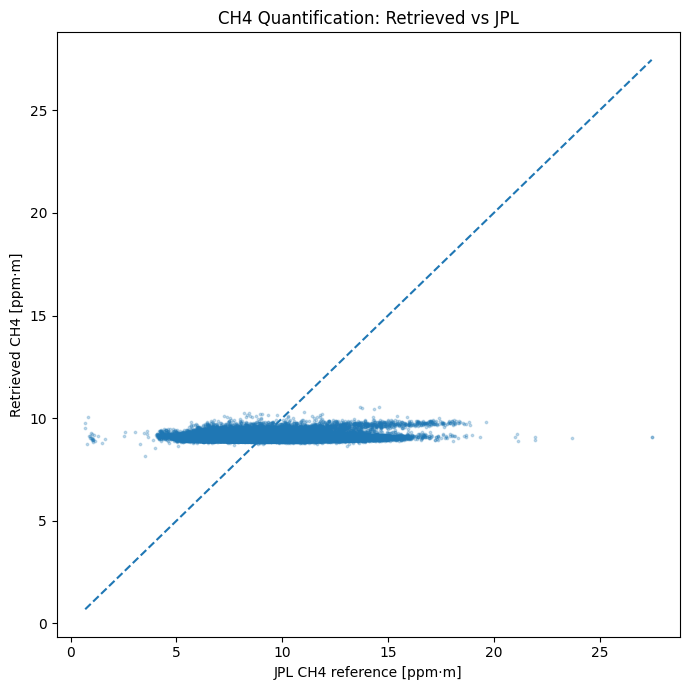

In [26]:
# ------------------------------------------------------------
# 11.2 JPL vs retrieved CH4
# ------------------------------------------------------------

import matplotlib.pyplot as plt

plt.figure(figsize=(7, 7))

plt.scatter(
    jpl_candidate,
    ch4_ppm_m,
    s=3,
    alpha=0.25
)

lims = [
    min(
        jpl_candidate.min(),
        ch4_ppm_m.min()
    ),
    max(
        jpl_candidate.max(),
        ch4_ppm_m.max()
    )
]

plt.plot(
    lims,
    lims,
    linestyle="--"
)

plt.xlabel("JPL CH4 reference [ppm·m]")
plt.ylabel("Retrieved CH4 [ppm·m]")
plt.title("CH4 Quantification: Retrieved vs JPL")

plt.tight_layout()
plt.show()

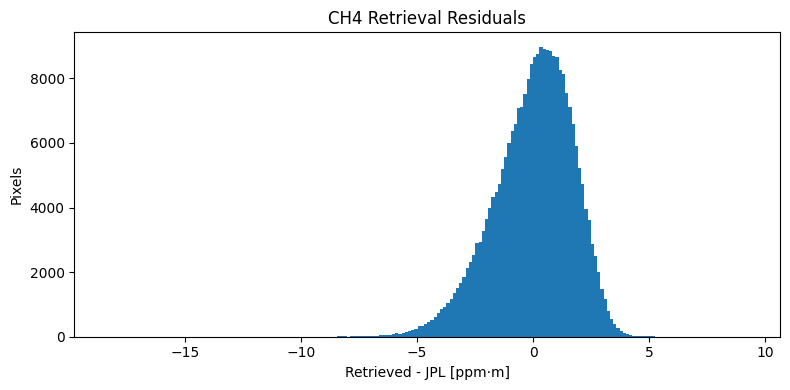

In [27]:
# ------------------------------------------------------------
# 11.3 Residuals
# ------------------------------------------------------------

residual = (
    ch4_ppm_m
    - jpl_candidate
)

plt.figure(figsize=(8, 4))

plt.hist(
    residual,
    bins=200
)

plt.xlabel("Retrieved - JPL [ppm·m]")
plt.ylabel("Pixels")
plt.title("CH4 Retrieval Residuals")

plt.tight_layout()
plt.show()